## Run Hypertunning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import rpy2.robjects as robjects

In [29]:
from custom_losses import (
    dirichlet_layer,
    EvidentialLoss,
    AnnealingCallback,
    evidential_kl_divergence,
    cross_entropy_loss,
)

ModuleNotFoundError: No module named 'custom_losses'

Read files in energy_data folder


In [2]:
readRDS = robjects.r['readRDS']

def load_rds_array(path):
    """Load an R array into numpy, preserving shape and dimnames."""
    r_obj  = readRDS(path)
    dims   = tuple(int(d) for d in robjects.r['dim'](r_obj))
    arr    = np.array(r_obj).reshape(dims, order='F')  # R is column-major

    # Recover named dimensions (e.g. feature names on axis 2 of X)
    r_dimnames = robjects.r['dimnames'](r_obj)
    dimnames = []
    for dn in r_dimnames:
        if dn == robjects.rinterface.NULL:
            dimnames.append(None)
        else:
            dimnames.append(list(dn))

    return arr, dimnames

X_train,     (_, _, feature_names)    = load_rds_array('energy_data/X_train.rds')
Y_train,     (_, _, state_names)      = load_rds_array('energy_data/Y_train.rds')
Y_hat_train, (_, _, state_names_hat)  = load_rds_array('energy_data/Y_hat_train.rds')

X_valid,     _ = load_rds_array('energy_data/X_valid.rds')
Y_valid,     _ = load_rds_array('energy_data/Y_valid.rds')
Y_hat_valid, _ = load_rds_array('energy_data/Y_hat_valid.rds')

X_test,      _ = load_rds_array('energy_data/X_test.rds')
Y_test,      _ = load_rds_array('energy_data/Y_test.rds')
Y_hat_test,  _ = load_rds_array('energy_data/Y_hat_test.rds')

print("X_train:    ", X_train.shape)
print("Y_train:    ", Y_train.shape)
print("Y_hat_train:", Y_hat_train.shape)
print("\nFeature names:", feature_names)
print("State names:  ", state_names)


X_train:     (3510, 10, 14)
Y_train:     (3510, 10, 4)
Y_hat_train: (3510, 10, 4)

Feature names: ['date', 'renewable_penetration', 'renewable_penetration_30d_avg', 'gas_share', 'gas_share_30d_avg', 'coal_share', 'coal_share_30d_avg', 'net_export_ratio', 'relative_demand', 'gas_price', 'month', 'state_prob_1', 'state_prob_2', 'state_prob_3']
State names:   ['date', 'gt_1', 'gt_2', 'gt_3']


### Convert to single forecast training splits

In [3]:
forecast_horizon = Y_train.shape[1]

dt_col_names = ['month']
x_cols       = [i for i, n in enumerate(feature_names) if n != 'date' and n not in dt_col_names]
x_dt_cols    = [i for i, n in enumerate(feature_names) if n in dt_col_names]
y_cols       = [i for i, n in enumerate(state_names)   if n != 'date']
x_date_idx   = feature_names.index('date')
y_date_idx   = state_names.index('date')

def prepare_data_with_horizon(X, Y, shuffle=True):
    x_dates = X[:, :, x_date_idx]
    y_dates = Y[:, :, y_date_idx]

    X_cov = X[:, :, x_cols].astype(float)
    X_dt  = X[:, :, x_dt_cols].astype(float)
    Y     = Y[:, :, y_cols].astype(float)

    n_samples = X_cov.shape[0]

    horizon_input = np.repeat(np.eye(forecast_horizon), n_samples, axis=0)
    X_cov_out     = np.concatenate([X_cov] * forecast_horizon, axis=0)
    X_dt_out      = np.concatenate([X_dt]  * forecast_horizon, axis=0)
    Y_out         = np.concatenate([Y[:, i, :] for i in range(forecast_horizon)], axis=0)
    x_dates_out   = np.tile(x_dates, (forecast_horizon, 1))[:, :, np.newaxis]
    y_dates_out   = np.concatenate([y_dates[:, i] for i in range(forecast_horizon)])[:, np.newaxis]
    y_month_out   = pd.get_dummies(pd.to_datetime(y_dates_out.flatten()).month, prefix='month').values.astype(int)

    if shuffle:
        idx           = np.random.permutation(X_cov_out.shape[0])
        X_cov_out     = X_cov_out[idx]
        X_dt_out      = X_dt_out[idx]
        horizon_input = horizon_input[idx]
        Y_out         = Y_out[idx]
        x_dates_out   = x_dates_out[idx]
        y_dates_out   = y_dates_out[idx]
        y_month_out   = y_month_out[idx]


    return X_cov_out, X_dt_out, horizon_input, Y_out, x_dates_out, y_dates_out, y_month_out

X_train_cov, X_train_dt, horizon_train, Y_train_h, dates_train, Y_dates_train, Y_month_train = prepare_data_with_horizon(X_train, Y_train, shuffle=True)
X_valid_cov, X_valid_dt, horizon_valid, Y_valid_h, dates_valid, Y_dates_valid, Y_month_valid = prepare_data_with_horizon(X_valid, Y_valid, shuffle=False)
X_test_cov,  X_test_dt,  horizon_test,  Y_test_h,  dates_test,  Y_dates_test, Y_month_test  = prepare_data_with_horizon(X_test,  Y_test,  shuffle=False)

print("X_train_cov:  ", X_train_cov.shape)   # (samples*horizon, lookback, 12)
print("X_train_dt:   ", X_train_dt.shape)    # (samples*horizon, lookback, 2)
print("horizon_train:", horizon_train.shape)  # (samples*horizon, horizon)
print("Y_train_h:    ", Y_train_h.shape)      # (samples*horizon, states)
print("Y_month_train:", Y_month_train.shape)     # (samples*horizon, 1)
print()
print("Cov features: ", [n for n in feature_names if n != 'date' and n not in dt_col_names])
print("DT features:  ", dt_col_names)


X_train_cov:   (35100, 10, 12)
X_train_dt:    (35100, 10, 1)
horizon_train: (35100, 10)
Y_train_h:     (35100, 3)
Y_month_train: (35100, 12)

Cov features:  ['renewable_penetration', 'renewable_penetration_30d_avg', 'gas_share', 'gas_share_30d_avg', 'coal_share', 'coal_share_30d_avg', 'net_export_ratio', 'relative_demand', 'gas_price', 'state_prob_1', 'state_prob_2', 'state_prob_3']
DT features:   ['month']


## Create custom Dirichlet layer and callbacks

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.losses import kullback_leibler_divergence
from tensorflow.keras.layers import Concatenate

In [15]:
import keras

In [ ]:
from custom_losses import (
    dirichlet_layer,
    EvidentialLoss,
    AnnealingCallback,
    evidential_kl_divergence,
    cross_entropy_loss,
)

### Create the model
Using RNN layer, followed by 2 dense ouput layers with callbacks

In [26]:
def build_model(lookback, n_cov_features, n_dt_features, n_states,
                embedding_dim=8, rnn_units=8, n_dense_layers=2, dense_units=16,
                dropout_rate=0.5, learning_rate=0.001,
                annealing_rate=100.0, max_annealing_rate=0.2):

    # Covariate time-series input: (lookback, n_cov_features)
    cov_input     = layers.Input(shape=(lookback, n_cov_features), name='cov_input')
    # Date/time input: (lookback, n_dt_features) — flatten across time before embedding
    dt_input      = layers.Input(shape=(n_dt_features, ),  name='dt_input')
    # One-hot horizon input: (forecast_horizon,)
    horizon_input = layers.Input(shape=(forecast_horizon,),        name='horizon_input')

    # Flatten dt across time then project to embedding
    dt_flat  = layers.Flatten()(dt_input)
    dt_embed = layers.Dense(embedding_dim, activation='relu')(dt_flat)

    # Project horizon to embedding
    horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)

    # RNN over covariate time-series
    rnn_out = layers.SimpleRNN(rnn_units, dropout=dropout_rate)(cov_input)

    # Merge all representations
    x = Concatenate()([rnn_out, dt_embed, horizon_embed])

    # Variable-depth dense head
    for _ in range(n_dense_layers):
        x = layers.Dense(dense_units, activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)

    # Output raw evidence (non-negative) — softplus ensures > 0
    output = layers.Dense(n_states, activation='softplus')(x)

    model = models.Model(inputs=[cov_input, dt_input, horizon_input], outputs=output)
    model.compile(
        loss=EvidentialLoss(annealing_rate=annealing_rate, max_annealing_rate=max_annealing_rate),
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=[evidential_kl_divergence, cross_entropy_loss]
    )
    return model


# Derive dimensions from prepared arrays
lookback       = X_train_cov.shape[1]
n_cov_features = X_train_cov.shape[2]
n_dt_features  = Y_month_train.shape[1]
n_states       = Y_train_h.shape[1]

model = build_model(lookback, n_cov_features, n_dt_features, n_states,
                    embedding_dim=8, rnn_units=8, n_dense_layers=1, dense_units=16,
                    dropout_rate=0.3, learning_rate=0.0001,
                    annealing_rate=100.0, max_annealing_rate=0.1)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dt_input            │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cov_input           │ (None, 10, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 12)        │          0 │ dt_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ horizon_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_1        │ (None, 8)         │        168 │ cov_input[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 8)         │        104 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8)         │         88 │ horizon_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 24)        │          0 │ simple_rnn_1[0][… │
│ (Concatenate)       │                   │            │ dense_4[0][0],    │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │        400 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 3)         │         51 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 811 (3.17 KB)

 Trainable params: 811 (3.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 75s 5ms/step - cross_entropy_loss: 1.0736 - evidential_kl_divergence: 0.6706 - loss: 1.0736 - val_cross_entropy_loss: 1.0450 - val_evidential_kl_divergence: 0.5982 - val_loss: 1.0450
Epoch 2/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0477 - evidential_kl_divergence: 0.6448 - loss: 1.0486 - val_cross_entropy_loss: 1.0235 - val_evidential_kl_divergence: 0.5767 - val_loss: 1.0244
Epoch 3/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0237 - evidential_kl_divergence: 0.6207 - loss: 1.0253 - val_cross_entropy_loss: 1.0076 - val_evidential_kl_divergence: 0.5607 - val_loss: 1.0091
Epoch 4/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0054 - evidential_kl_divergence: 0.6025 - loss: 1.0077 - val_cross_entropy_loss: 0.9982 - val_evidential_kl_divergence: 0.5514 - val_loss: 1.0005
Epoch 5/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 0.9893 - evidential_kl_dive

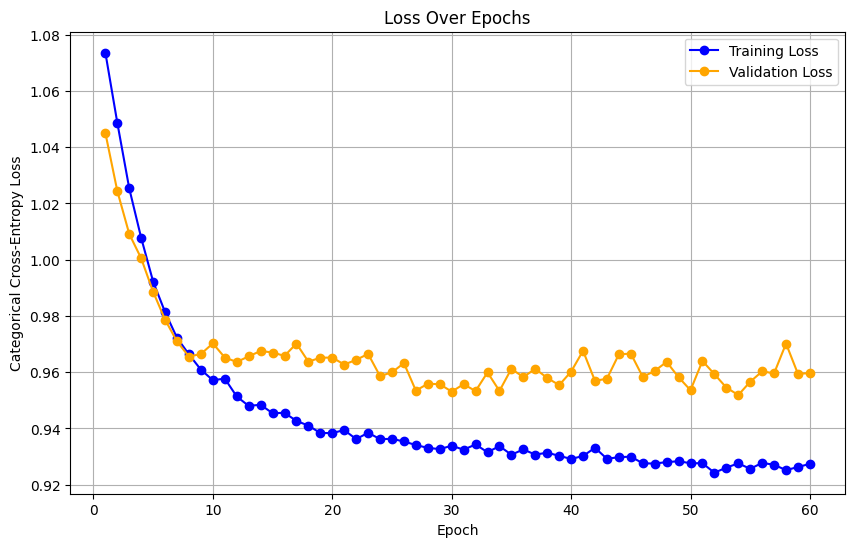

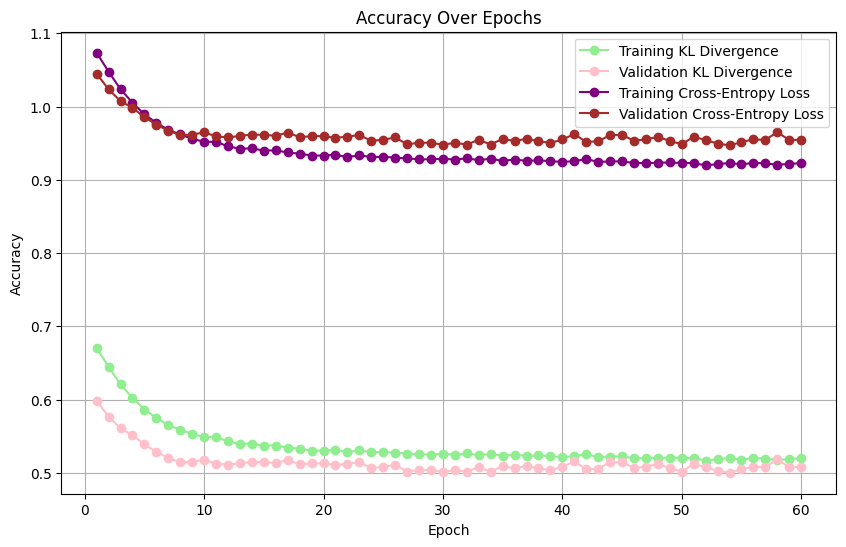

In [ ]:

tf.keras.backend.clear_session()

history = model.fit(
    [X_train_cov, Y_month_train, horizon_train], Y_train_h,
    validation_data=([X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h),
    callbacks=[AnnealingCallback()],
    epochs=60,  # Use the same number as in your tuner setup
    verbose=1  # Set to 0 for silent output if preferred
)

def plot_training_history(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Categorical Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['evidential_kl_divergence'], label='Training KL Divergence', marker='o', color='lightgreen')
    plt.plot(epochs, history.history['val_evidential_kl_divergence'], label='Validation KL Divergence', marker='o', color='pink')
    plt.plot(epochs, history.history['cross_entropy_loss'], label='Training Cross-Entropy Loss', marker='o', color='purple')
    plt.plot(epochs, history.history['val_cross_entropy_loss'], label='Validation Cross-Entropy Loss', marker='o', color='brown')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_training_history(history)

## Run Hypertunnig

In [9]:
tf.keras.backend.clear_session()

def build_model_hp(hp):
    return build_model(
        lookback           = lookback,
        n_cov_features     = n_cov_features,
        n_dt_features      = n_dt_features,
        n_states           = n_states,
        embedding_dim      = hp.Choice('embedding_dim',      values=[2, 8]),
        rnn_units          = hp.Choice('rnn_units',          values=[2, 4, 8, 16]),
        n_dense_layers     = hp.Int(  'n_dense_layers',      min_value=1, max_value=3),
        dense_units        = hp.Choice('dense_units',        values=[2, 4, 8, 16]),
        dropout_rate       = hp.Float('dropout_rate',        min_value=0.3, max_value=0.5, step=0.1),
        learning_rate      = hp.Choice('learning_rate',      values=[1e-4]),
        annealing_rate     = hp.Choice('annealing_rate',     values=[100.0]),
        max_annealing_rate = hp.Float('max_annealing_rate',  min_value=0.1, max_value=0.4, step=0.1),
    )


tuner = kt.Hyperband(
    build_model_hp,
    objective=kt.Objective('val_cross_entropy_loss', direction='min'),
    max_epochs=50,
    factor=3,
    overwrite=True,
    directory='tuner_results',
    project_name='energy_hmm',
)

tuner.search(
    [X_train_cov, Y_month_train, horizon_train], Y_train_h,
    validation_data=([X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h),
    callbacks=[AnnealingCallback()],
)

tuner.results_summary()
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hps.values)

Trial 90 Complete [00h 02m 10s]
val_cross_entropy_loss: 0.9835968613624573

Best val_cross_entropy_loss So Far: 0.932490348815918
Total elapsed time: 00h 48m 34s
Results summary
Results in tuner_results/energy_hmm
Showing 10 best trials
Objective(name="val_cross_entropy_loss", direction="min")

Trial 0050 summary
Hyperparameters:
embedding_dim: 8
rnn_units: 8
n_dense_layers: 1
dense_units: 16
dropout_rate: 0.3
learning_rate: 0.0001
annealing_rate: 100.0
max_annealing_rate: 0.1
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0046
Score: 0.932490348815918

Trial 0072 summary
Hyperparameters:
embedding_dim: 8
rnn_units: 16
n_dense_layers: 1
dense_units: 8
dropout_rate: 0.3
learning_rate: 0.0001
annealing_rate: 100.0
max_annealing_rate: 0.2
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0067
Score: 0.9369329214096069

Trial 0046 summary
Hyperparameters:
embedding_dim: 8
rnn_units: 8
n_dense_layers: 1
dense_u

In [10]:
print(best_hps.values)

{'embedding_dim': 8, 'rnn_units': 8, 'n_dense_layers': 1, 'dense_units': 16, 'dropout_rate': 0.3, 'learning_rate': 0.0001, 'annealing_rate': 100.0, 'max_annealing_rate': 0.1, 'tuner/epochs': 50, 'tuner/initial_epoch': 17, 'tuner/bracket': 3, 'tuner/round': 3, 'tuner/trial_id': '0046'}


Epoch 1/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 55s 4ms/step - cross_entropy_loss: 1.0728 - evidential_kl_divergence: 0.6698 - loss: 1.0728 - val_cross_entropy_loss: 1.0332 - val_evidential_kl_divergence: 0.5863 - val_loss: 1.0332
Epoch 2/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0453 - evidential_kl_divergence: 0.6424 - loss: 1.0463 - val_cross_entropy_loss: 1.0115 - val_evidential_kl_divergence: 0.5647 - val_loss: 1.0124
Epoch 3/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - cross_entropy_loss: 1.0179 - evidential_kl_divergence: 0.6149 - loss: 1.0197 - val_cross_entropy_loss: 0.9851 - val_evidential_kl_divergence: 0.5382 - val_loss: 0.9868
Epoch 4/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 0.9985 - evidential_kl_divergence: 0.5956 - loss: 1.0011 - val_cross_entropy_loss: 0.9708 - val_evidential_kl_divergence: 0.5240 - val_loss: 0.9732
Epoch 5/60
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 0.9878 - evidential_kl_dive

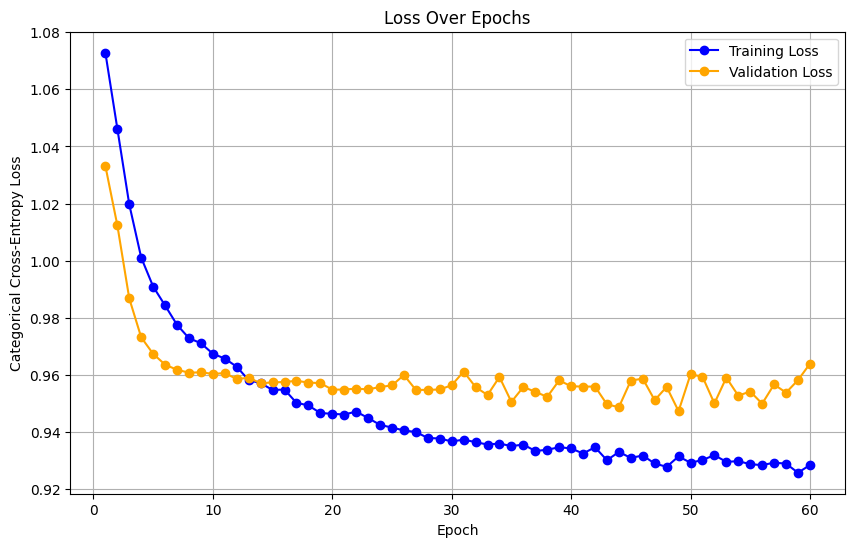

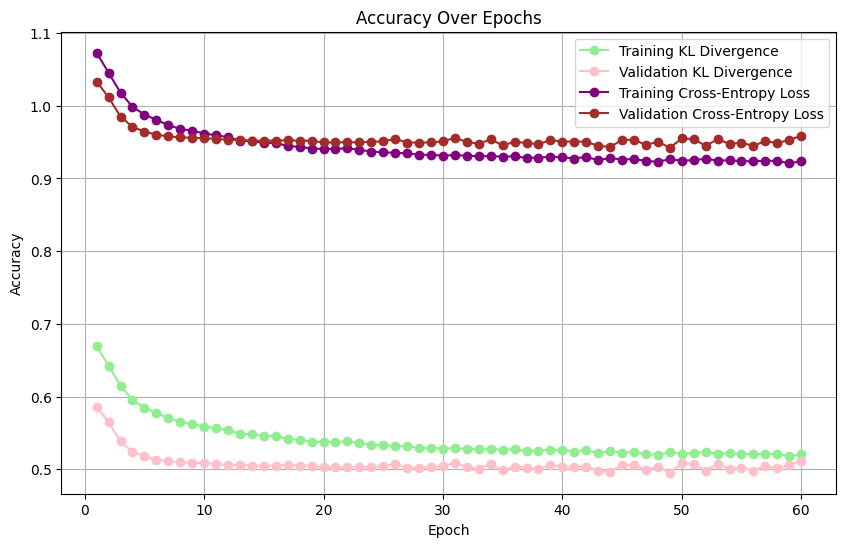

In [27]:
tf.keras.backend.clear_session()

model = build_model(lookback, n_cov_features, n_dt_features, n_states,
                    embedding_dim=8, rnn_units=8, n_dense_layers=1, dense_units=16,
                    dropout_rate=0.3, learning_rate=0.0001,
                    annealing_rate=100.0, max_annealing_rate=0.1)

history = model.fit(
    [X_train_cov, Y_month_train, horizon_train], Y_train_h,
    validation_data=([X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h),
    callbacks=[AnnealingCallback()],
    epochs=60,  # Use the same number as in your tuner setup
    verbose=1  # Set to 0 for silent output if preferred
)

def plot_training_history(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Categorical Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['evidential_kl_divergence'], label='Training KL Divergence', marker='o', color='lightgreen')
    plt.plot(epochs, history.history['val_evidential_kl_divergence'], label='Validation KL Divergence', marker='o', color='pink')
    plt.plot(epochs, history.history['cross_entropy_loss'], label='Training Cross-Entropy Loss', marker='o', color='purple')
    plt.plot(epochs, history.history['val_cross_entropy_loss'], label='Validation Cross-Entropy Loss', marker='o', color='brown')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_training_history(history)

In [28]:
## Save the best model
model.save('energy_data/best_model.keras')
print("Model saved to energy_data/best_model.keras")

Model saved to energy_data/best_model.keras


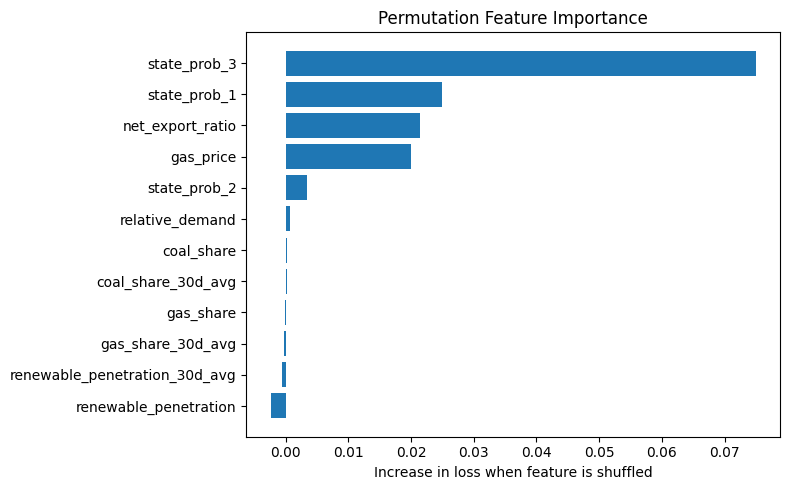

In [10]:
best_model = model
cov_feature_names = [n for n in feature_names if n != 'date' and n not in dt_col_names]

base_loss = best_model.evaluate(
    [X_valid_cov, Y_month_valid, horizon_valid], Y_valid_h, verbose=0
)[0]

importances = {}
for i, name in enumerate(cov_feature_names):
    X_perm = X_valid_cov.copy()
    np.random.shuffle(X_perm[:, :, i])  # shuffle that feature across samples
    perm_loss = best_model.evaluate(
        [X_perm, Y_month_valid, horizon_valid], Y_valid_h, verbose=0
    )[0]
    importances[name] = perm_loss - base_loss

# Plot
names, scores = zip(*sorted(importances.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(8, 5))
plt.barh(names[::-1], scores[::-1])
plt.xlabel("Increase in loss when feature is shuffled")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()



/tmp/ipykernel_1916931/1190128375.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


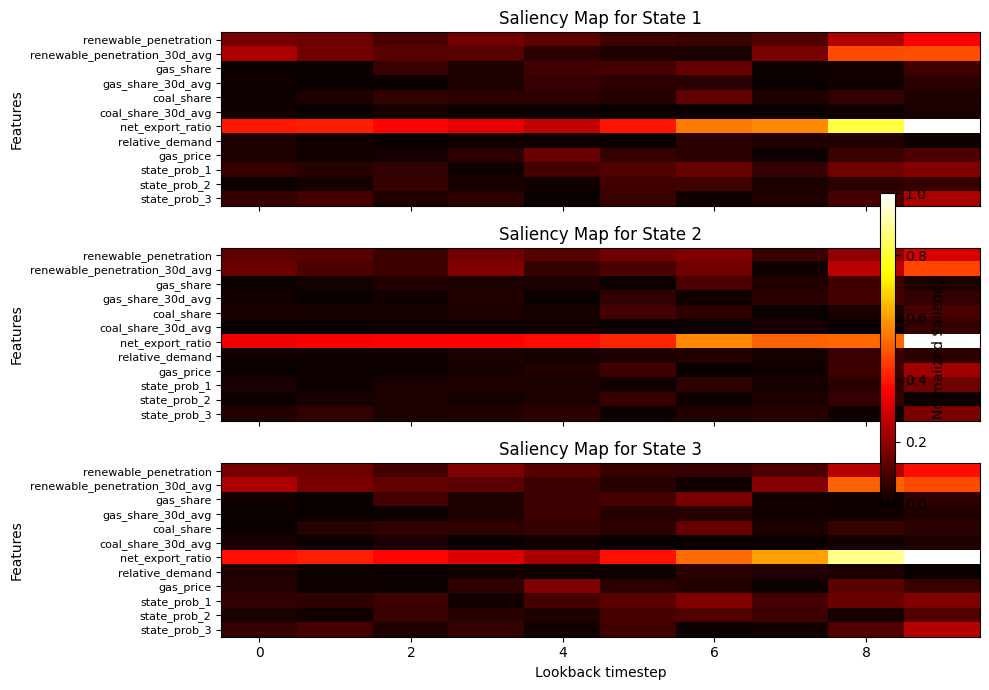

In [11]:
best_model = model
cov_feature_names = [n for n in feature_names if n != 'date' and n not in dt_col_names]

# Select a sample input
sample_idx = 2
sample_cov     = tf.convert_to_tensor(X_valid_cov[sample_idx:sample_idx+1],   dtype=tf.float32)
sample_month   = tf.convert_to_tensor(Y_month_valid[sample_idx:sample_idx+1], dtype=tf.float32)
sample_horizon = tf.convert_to_tensor(horizon_valid[sample_idx:sample_idx+1], dtype=tf.float32)

saliency_maps = []

for target_class in range(n_states):
    with tf.GradientTape() as tape:
        tape.watch(sample_cov)
        predictions = best_model([sample_cov, sample_month, sample_horizon], training=False)
        class_output = predictions[:, target_class]

    gradients = tape.gradient(class_output, sample_cov)
    saliency_map = tf.abs(gradients).numpy()[0]  # (lookback, n_cov_features)
    saliency_map = saliency_map.T                # (n_cov_features, lookback)
    saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min() + 1e-8)
    saliency_maps.append(saliency_map)

fig, axs = plt.subplots(n_states, 1, figsize=(10, 7), sharex=True)

for i, ax in enumerate(axs):
    im = ax.imshow(saliency_maps[i], cmap='hot', aspect='auto')
    ax.set_title(f'Saliency Map for State {i + 1}')
    ax.set_ylabel('Features')
    ax.set_yticks(range(len(cov_feature_names)))
    ax.set_yticklabels(cov_feature_names, fontsize=8)

axs[-1].set_xlabel('Lookback timestep')
fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.02, pad=0.04, label='Normalized Saliency')
plt.tight_layout()
plt.show()